<a href="https://colab.research.google.com/github/Walid75364/GenIA/blob/Bootcamp_Weeks/W6_D1_DC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Daily Challenge

**Text preprocessing**

In [7]:
import requests
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk import pos_tag, ne_chunk
import spacy
nlp = spacy.load('en_core_web_sm')


# Télécharger les ressources nécessaires de NLTK
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('maxent_ne_chunker_tab')

# Charger le modèle pré-entraîné de spaCy
nlp = spacy.load('en_core_web_sm')

# 1️⃣ Fonction pour charger et nettoyer les textes
def load_texts(urls):
    corpus = []
    for url in urls:
        try:
            response = requests.get(url)
            response.raise_for_status()
            text = response.text

            # Supprimer les crédits en cherchant les mots clés
            start = text.find('START OF')
            end = text.find('END OF')
            if start != -1 and end != -1:
                text = text[start:end]

            # Nettoyer les caractères non-mots
            cleaned_text = re.sub(r'\W+', ' ', text)
            corpus.append(cleaned_text)
        except requests.exceptions.RequestException as e:
            print(f"Erreur lors de la récupération de {url} : {e}")
    return corpus

# 📥 URLs des textes à charger
urls = [
    'https://www.gutenberg.org/cache/epub/11/pg11.txt',       # Alice's Adventures in Wonderland
    'https://www.gutenberg.org/cache/epub/12/pg12.txt',       # Through the Looking-Glass
    'https://www.gutenberg.org/cache/epub/29042/pg29042.txt'  # A Tangled Tale
]

# 🧾 Charger les textes
corpus = load_texts(urls)

# 2️⃣ Afficher les 200 premiers caractères de chaque texte nettoyé
print("\n🌟 Premier aperçu des textes :")
for i, text in enumerate(corpus):
    print(f"\nTexte {i+1} (200 caractères) :\n{text[:200]}")

# 3️⃣ Tokenisation
print("\n🔤 Première tokenisation :")
tokenized_texts = [word_tokenize(text.lower()) for text in corpus]
for i, tokens in enumerate(tokenized_texts):
    print(f"\nTexte {i+1} - 150 premiers tokens :\n{tokens[:150]}")

# 4️⃣ Suppression des stopwords
stop_words = set(stopwords.words('english'))
filtered_texts = [[token for token in tokens if token not in stop_words] for tokens in tokenized_texts]

print("\n🚫 Vérification des stopwords retirés :")
stopwords_exemples = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves']
for word in stopwords_exemples:
    for i, tokens in enumerate(filtered_texts):
        count = tokens.count(word)
        print(f"'{word}' dans texte {i+1} : {count}")

# 5️⃣ Stemming avec PorterStemmer
stemmer = PorterStemmer()
print("\n🌱 Stemming (50 premiers stems) :")
for i, tokens in enumerate(filtered_texts):
    stemmed = [stemmer.stem(token) for token in tokens[:50]]
    print(f"\nTexte {i+1} stems :\n{stemmed}")

# 6️⃣ Lemmatization avec spaCy
print("\n🍃 Lemmatization (50 premiers lemmes) :")
for i, text in enumerate(corpus):
    doc = nlp(text.lower())
    lemmatized = [token.lemma_ for token in doc if token.is_alpha][:50]
    print(f"\nTexte {i+1} lemmes :\n{lemmatized}")

# 7️⃣ Analyse des différences entre stemming et lemmatization
print("\n📚 Différences entre stemming et lemmatisation :")
print("""
Le stemming réduit les mots à leur racine brute (souvent déformée), utile pour les moteurs de recherche.
Ex: 'running' → 'run', 'better' → 'better'
La lemmatisation identifie la forme canonique du mot, en tenant compte du contexte grammatical.
Ex: 'running' → 'run', 'better' → 'good'
Donc, lemmatisation est plus précise mais plus lente.
""")

# 8️⃣ Tags grammaticaux (POS) avec NLTK
print("\n🏷️ POS Tags :")
for i, tokens in enumerate(tokenized_texts):
    pos_tags = pos_tag(tokens[:50])
    print(f"\nTexte {i+1} POS Tags :\n{pos_tags}")

# 9️⃣ Reconnaissance d'entités nommées avec NLTK
print("\n🧠 Entités nommées :")
for i, tokens in enumerate(tokenized_texts):
    entities = ne_chunk(pos_tag(tokens[:100]))
    print(f"\nTexte {i+1} Entités :\n{entities}")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk


🌟 Premier aperçu des textes :

Texte 1 (200 caractères) :
START OF THE PROJECT GUTENBERG EBOOK ALICE S ADVENTURES IN WONDERLAND Illustration Alice s Adventures in Wonderland by Lewis Carroll THE MILLENNIUM FULCRUM EDITION 3 0 Contents CHAPTER I Down the Rabb

Texte 2 (200 caractères) :
START OF THE PROJECT GUTENBERG EBOOK THROUGH THE LOOKING GLASS Illustration THROUGH THE LOOKING GLASS And What Alice Found There By Lewis Carroll The Millennium Fulcrum Edition 1 7 DRAMATIS PERSONÆ _A

Texte 3 (200 caractères) :
START OF THE PROJECT GUTENBERG EBOOK A TANGLED TALE Produced by Chris Curnow Carla Foust Lindy Walsh and the Online Distributed Proofreading Team at https www pgdp net Music transcribed by Linda Canto

🔤 Première tokenisation :

Texte 1 - 150 premiers tokens :
['start', 'of', 'the', 'project', 'gutenberg', 'ebook', 'alice', 's', 'adventures', 'in', 'wonderland', 'illustration', 'alice', 's', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcru

**Analysing the text**


🌥️ WordClouds pour chaque livre :


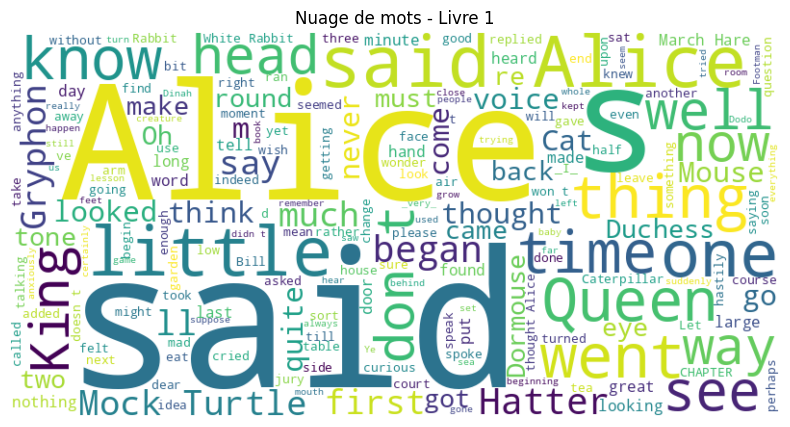

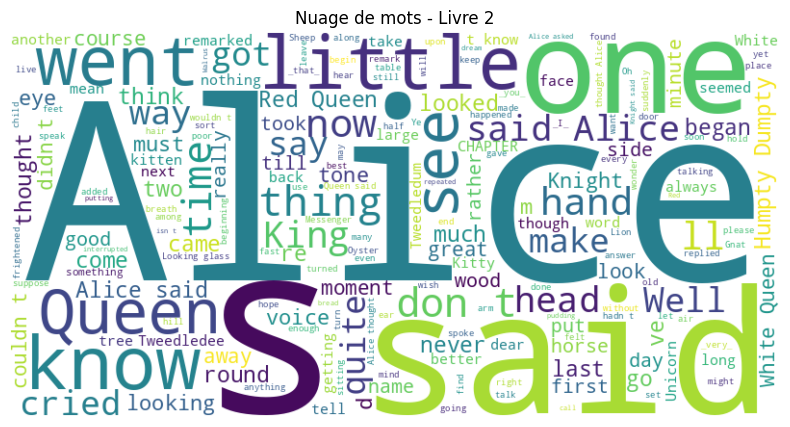

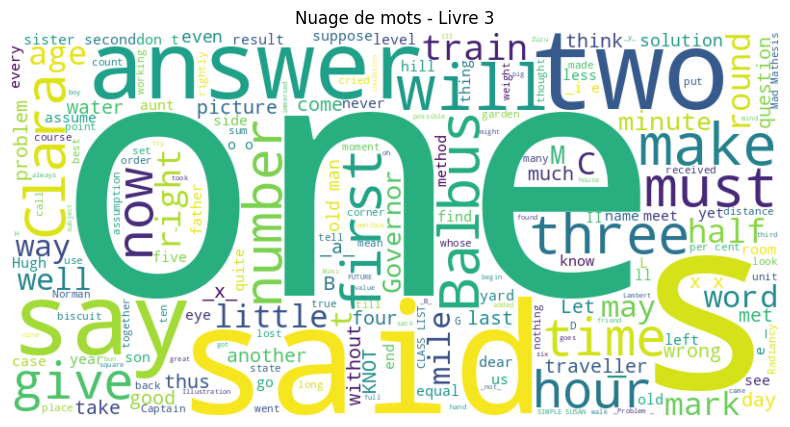


📊 Camemberts des 5 mots les plus fréquents par livre :

📘 Livre 1 — Top 5 mots :
- said : 460
- alice : 399
- little : 127
- know : 87
- like : 85


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129383 (\N{PIE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


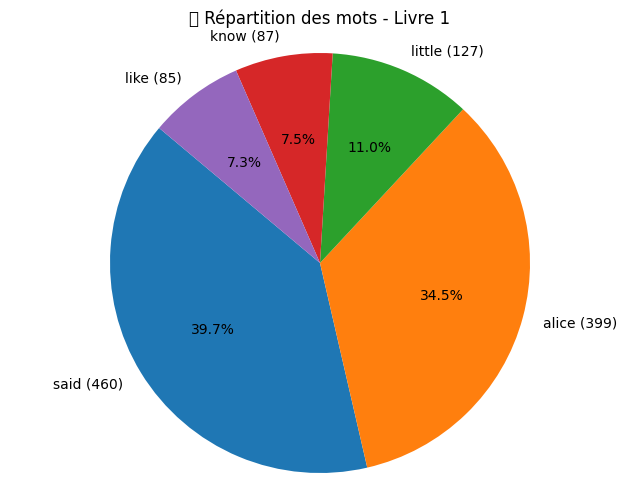


📘 Livre 2 — Top 5 mots :
- said : 473
- alice : 468
- queen : 189
- know : 125
- like : 122


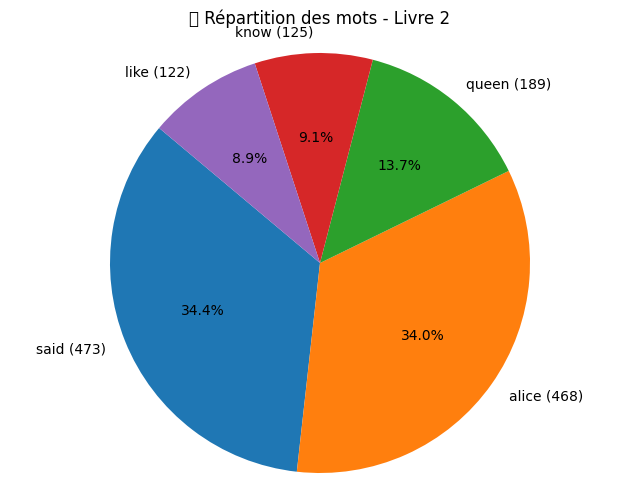


📘 Livre 3 — Top 5 mots :
- said : 134
- old : 92
- balbus : 70
- clara : 62
- answers : 51


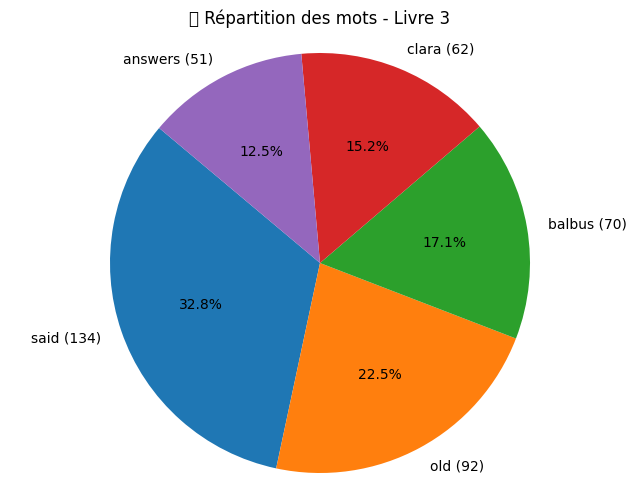

In [15]:
# 📚 Imports nécessaires
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# 📘 Corpus déjà chargé dans la variable `corpus`

# 🔍 1️⃣ Créer un nuage de mots pour chaque livre
print("\n🌥️ WordClouds pour chaque livre :")
for i, text in enumerate(corpus):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Nuage de mots - Livre {i+1}")
    plt.show()

# 🧮 2️⃣ Méthode Bag of Words (BoW) pour les mots les plus fréquents
# ✅ On utilise les textes lemmatized (plus précis que raw ou stemmed)
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(stop_words='english')  # On exclut les stopwords
bow = vectorizer.fit_transform(corpus)

# 🧮 3️⃣  Créer un BoW et afficher les 5 mots les plus fréquents par texte
vectorizer = CountVectorizer(stop_words='english')

print("\n📊 Camemberts des 5 mots les plus fréquents par livre :")
for i, text in enumerate(corpus):
    bow = vectorizer.fit_transform([text])  # On vectorise chaque texte individuellement
    words = vectorizer.get_feature_names_out()
    frequencies = np.array(bow.sum(axis=0)).flatten()

    word_freq = list(zip(words, frequencies))
    word_freq_sorted = sorted(word_freq, key=lambda x: x[1], reverse=True)[:5]
    top_words = [w for w, _ in word_freq_sorted]
    top_freqs = [f for _, f in word_freq_sorted]

    print(f"\n📘 Livre {i+1} — Top 5 mots :")
    for w, f in word_freq_sorted:
        print(f"- {w} : {f}")

    # 🥧 Camembert
    plt.figure(figsize=(8, 6))
    plt.pie(top_freqs, labels=[f"{w} ({f})" for w, f in zip(top_words, top_freqs)],
            autopct='%1.1f%%', startangle=140)
    plt.title(f"🥧 Répartition des mots - Livre {i+1}")
    plt.axis('equal')
    plt.show()

Analyse des mots pour livre 3 :

✨ **Sont-ils informatifs ?**

"Alice", "Queen" → Oui Ces mots révèlent des personnages clés. Leur forte fréquence confirme qu'ils sont centraux à l’intrigue.

"Little", "Like", "Said" → Plutôt attendus Ce sont des mots fréquents dans les récits narratifs :

"Said" : typique dans les dialogues, très courant dans les romans.

"Little" : peut indiquer le style de l’auteur (Lewis Carroll adore décrire en utilisant des termes relatifs à la taille).

"Like" : utilisé pour comparaison, émotions ou actions.

🧠 **Sont-ils "insightful" (révélateurs) ?**

Ils donnent un aperçu du ton du récit : beaucoup de dialogues, de comparaisons imagées, et une forte focalisation sur Alice et ses interactions.

Mais ils ne donnent pas encore de thèmes profonds ou de concepts philosophiques. Ce serait plus évident avec des mots comme “dream”, “time”, “strange”, “logic”, etc.

**Solving the frequency problem using TF-IDF**


📘 Livre 1 — Top 5 TF-IDF :
- gryphon : 0.3323
- rabbit : 0.3262
- turtle : 0.2849
- mock : 0.2619
- hatter : 0.2619


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129383 (\N{PIE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


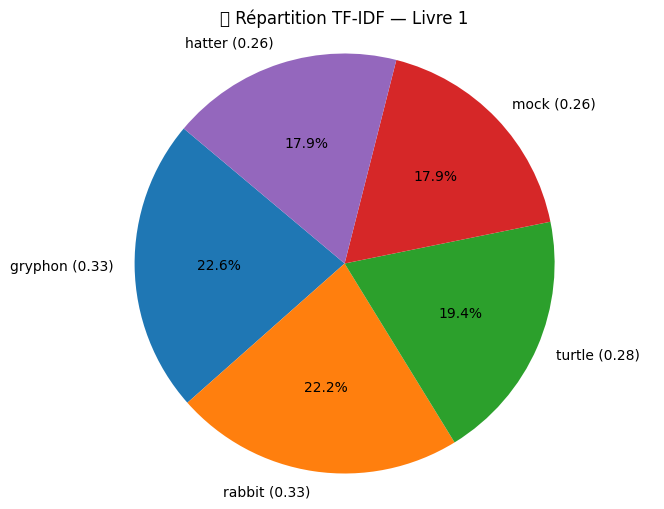


📘 Livre 2 — Top 5 TF-IDF :
- dumpty : 0.3532
- humpty : 0.3532
- knight : 0.2926
- tweedledum : 0.2334
- tweedledee : 0.1829


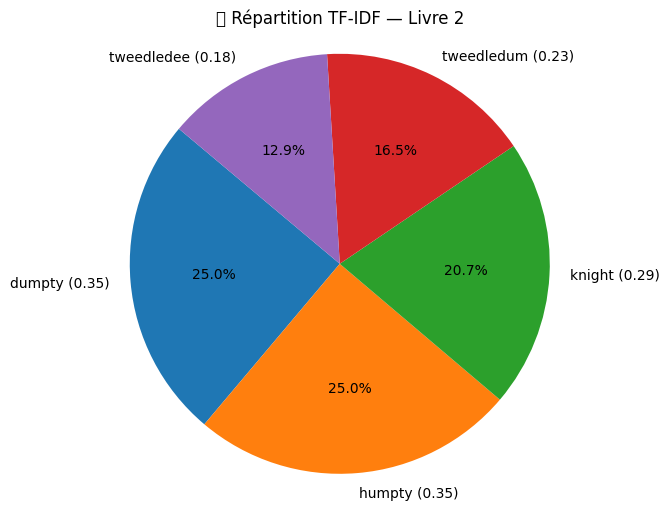


📘 Livre 3 — Top 5 TF-IDF :
- balbus : 0.3248
- clara : 0.2882
- problem : 0.2105
- train : 0.1844
- solution : 0.1739


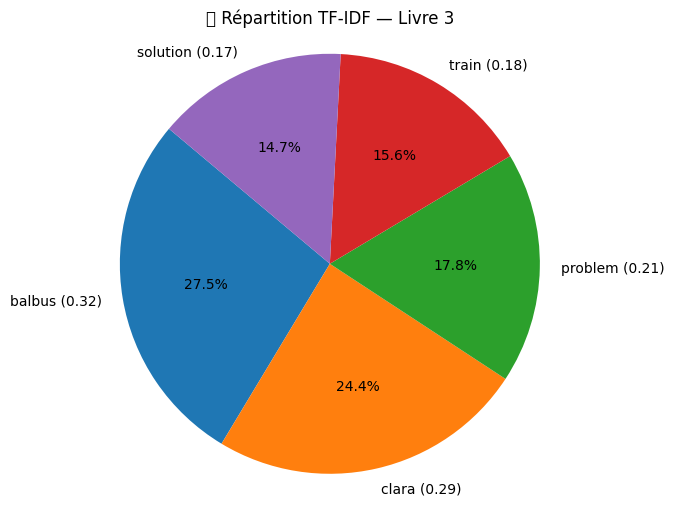

In [13]:
# 📦 Imports
import requests
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import spacy

# 🔧 Charger le modèle SpaCy
nlp = spacy.load('en_core_web_sm')

# 🔁 Fonction pour charger et nettoyer les textes
def load_texts(urls):
    corpus = []
    for url in urls:
        try:
            response = requests.get(url)
            response.raise_for_status()
            text = response.text
            # Supprimer les crédits Gutenberg
            start = text.find("*** START")
            end = text.find("*** END")
            if start != -1 and end != -1:
                text = text[start:end]
            # Nettoyer caractères non-mots
            text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # Supprimer caractères non-ASCII
            text = re.sub(r'\W+', ' ', text)  # Supprimer ponctuation
            corpus.append(text)
        except Exception as e:
            print(f"Erreur lors du chargement de {url} : {e}")
    return corpus

# 📥 URLs des livres
urls = [
    'https://www.gutenberg.org/cache/epub/11/pg11.txt',       # Alice
    'https://www.gutenberg.org/cache/epub/12/pg12.txt',       # Looking-Glass
    'https://www.gutenberg.org/cache/epub/29042/pg29042.txt'  # Tangled Tale
]

# 📘 Charger les textes
raw_texts = load_texts(urls)

# 🍃 Lemmatisation
lemmatized_texts = []
for text in raw_texts:
    doc = nlp(text.lower())
    lemmatized = " ".join([token.lemma_ for token in doc if token.is_alpha and not token.is_stop])
    lemmatized_texts.append(lemmatized)

# 🔢 1️⃣ Calculer la matrice TF-IDF
vectorizer = TfidfVectorizer(min_df=1, max_df=2)
tfidf_matrix = vectorizer.fit_transform(lemmatized_texts)
feature_names = vectorizer.get_feature_names_out()

# 🥧 2️⃣ Afficher les 5 mots les plus pertinents avec camemberts
for doc_index in range(len(lemmatized_texts)):
    scores = tfidf_matrix[doc_index].toarray().flatten()
    top_indices = scores.argsort()[::-1][:5]
    top_words = [feature_names[i] for i in top_indices]
    top_scores = [scores[i] for i in top_indices]

    print(f"\n📘 Livre {doc_index+1} — Top 5 TF-IDF :")
    for w, s in zip(top_words, top_scores):
        print(f"- {w} : {s:.4f}")

    # 🎨 Camembert
    plt.figure(figsize=(8, 6))
    plt.pie(top_scores, labels=[f"{w} ({s:.2f})" for w, s in zip(top_words, top_scores)],
            autopct='%1.1f%%', startangle=140)
    plt.title(f"🥧 Répartition TF-IDF — Livre {doc_index+1}")
    plt.axis('equal')
    plt.show()



**Interprétations après utilisation des 2 méthodes**

🧮 **1. La méthode BoW (Bag of Words)** :

Elle compte les occurrences exactes des mots.

Mais si on vectorise tous les documents ensemble, elle calcule la somme des fréquences globales (par défaut), ce qui peut lisser les particularités d’un texte.

Dans le script initial, on faisait vectorizer.fit_transform(corpus), donc le vocabulaire était partagé entre les 3 textes → pas idéal si on cherche les 5 mots propres à chaque URL individuellement.

✅ Quand on vectorise chaque document séparément, comme dans le script optimisé, on obtient bien les fréquences propres à ce document.


🧠 **2. La méthode TF-IDF (Term Frequency - Inverse Document Frequency)** :

Elle ne donne pas des occurrences absolues, mais un score de pertinence.

Un mot présent dans tous les textes aura un score faible (même s’il est fréquent), car il est jugé peu informatif.

À l’inverse, un mot rare mais spécifique à un document aura un score élevé — même s’il ne revient que 2 ou 3 fois.

🔁 C’est pourquoi les camemberts basés sur TF-IDF peuvent ne pas inclure les 5 mots les plus fréquents au sens strict. Ils montrent les 5 mots les plus pertinents, c’est une logique différente.

✨ **Résumé :**

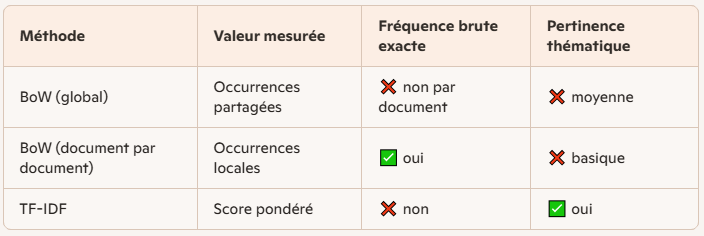
